**TASK 1 LEVEL 1 DATA CLEANINIG AND PREPROCESSING**

In [2]:
import pandas as pd
df_cleaned = pd.read_csv('iris_cleaned.csv')

In [1]:
import pandas as pd
import numpy as np

# 1. Load the uploaded CSV file
df = pd.read_csv('1) iris.csv')

# 2. Check missing values & duplicates
print("--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows Identified ---")
print(f"Total duplicate rows: {df.duplicated().sum()}")
print(df[df.duplicated(keep=False)])

# 3. Drop duplicates and reset index
df_cleaned = df.drop_duplicates().reset_index(drop=True)

# 4. Standardize column names and target column text
df_cleaned.columns = df_cleaned.columns.str.strip().str.lower()
if 'species' in df_cleaned.columns:
    df_cleaned['species'] = df_cleaned['species'].str.strip().str.lower()

# 5. Save the cleaned dataset locally
df_cleaned.to_csv('iris_cleaned.csv', index=False)
print("\nCleaned dataset saved as 'iris_cleaned.csv'!")
print(f"Cleaned dataset shape: {df_cleaned.shape}")

--- Missing Values ---
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

--- Duplicate Rows Identified ---
Total duplicate rows: 3
     sepal_length  sepal_width  petal_length  petal_width    species
9             4.9          3.1           1.5          0.1     setosa
34            4.9          3.1           1.5          0.1     setosa
37            4.9          3.1           1.5          0.1     setosa
101           5.8          2.7           5.1          1.9  virginica
142           5.8          2.7           5.1          1.9  virginica

Cleaned dataset saved as 'iris_cleaned.csv'!
Cleaned dataset shape: (147, 5)


**TASK 2 EXPLORATORY DATA ANALYSIS (EDA)**

--- Summary Statistics ---


,count,mean,std,median,mode,min,max
sepal_length,147.0,5.856463,0.829100,5.8,5.0,4.3,7.9
sepal_width,147.0,3.055782,0.437009,3.0,3.0,2.0,4.4
petal_length,147.0,3.780272,1.759111,4.4,1.4,1.0,6.9
petal_width,147.0,1.208844,0.757874,1.3,0.2,0.1,2.5


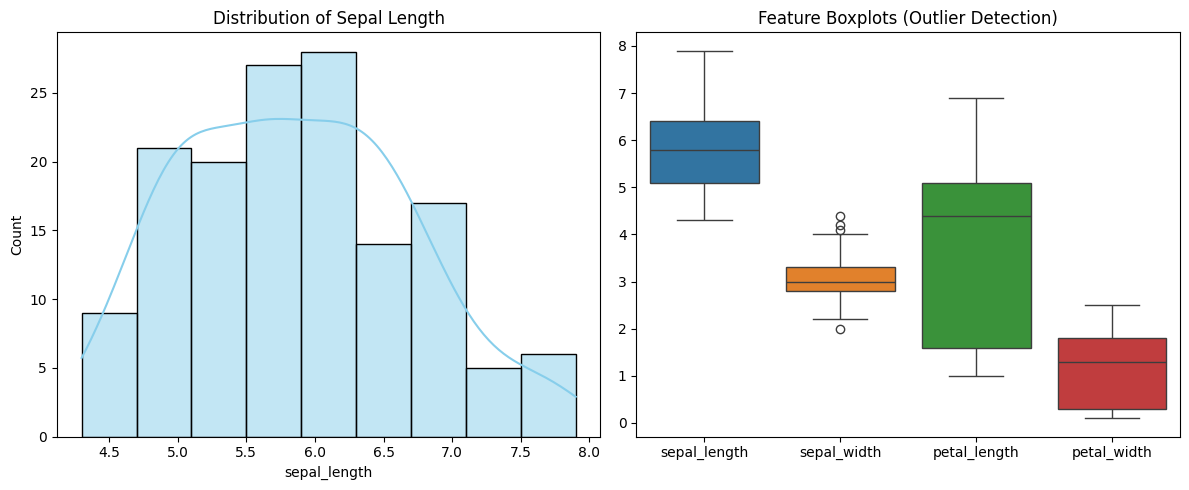

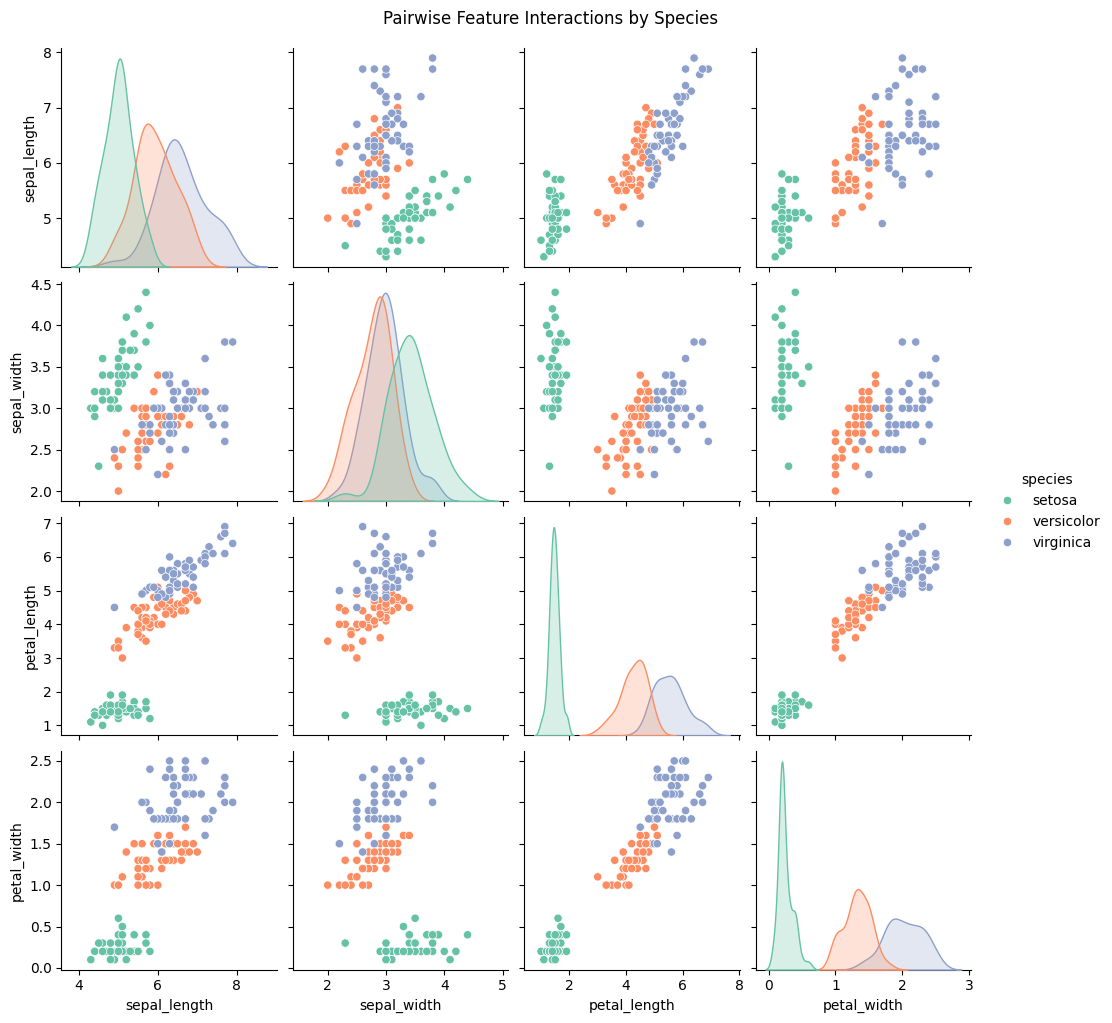

In [3]:
# --- TASK 2: EXPLORATORY DATA ANALYSIS (EDA) ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Summary Statistics (Mean, Std, Median)
summary_stats = df_cleaned.describe().T
summary_stats['median'] = df_cleaned.median(numeric_only=True)

# 2. Calculate Mode
mode_vals = df_cleaned.select_dtypes(include=[np.number]).mode().iloc[0]
summary_stats['mode'] = mode_vals

# 3. Reorder and display summary table
summary_stats = summary_stats[['count', 'mean', 'std', 'median', 'mode', 'min', 'max']]
print("--- Summary Statistics ---")
display(summary_stats)

# 4. Data Visualizations
plt.figure(figsize=(12, 5))

# Histogram / Distribution of Sepal Length
plt.subplot(1, 2, 1)
sns.histplot(df_cleaned['sepal_length'], kde=True, color='skyblue')
plt.title('Distribution of Sepal Length')

# Boxplot to check for Outliers
plt.subplot(1, 2, 2)
sns.boxplot(data=df_cleaned.select_dtypes(include=[np.number]))
plt.title('Feature Boxplots (Outlier Detection)')

plt.tight_layout()
plt.show()

# Pairplot to see relationships across species
sns.pairplot(df_cleaned, hue='species', palette='Set2')
plt.suptitle('Pairwise Feature Interactions by Species', y=1.02)
plt.show()

**TASK 3 BASIC DATA VISUALIZATION**

Accuracy Score: 96.67%

--- Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



/tmp/ipykernel_2450/1063821397.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=X.columns, palette='viridis', ax=axes[1])


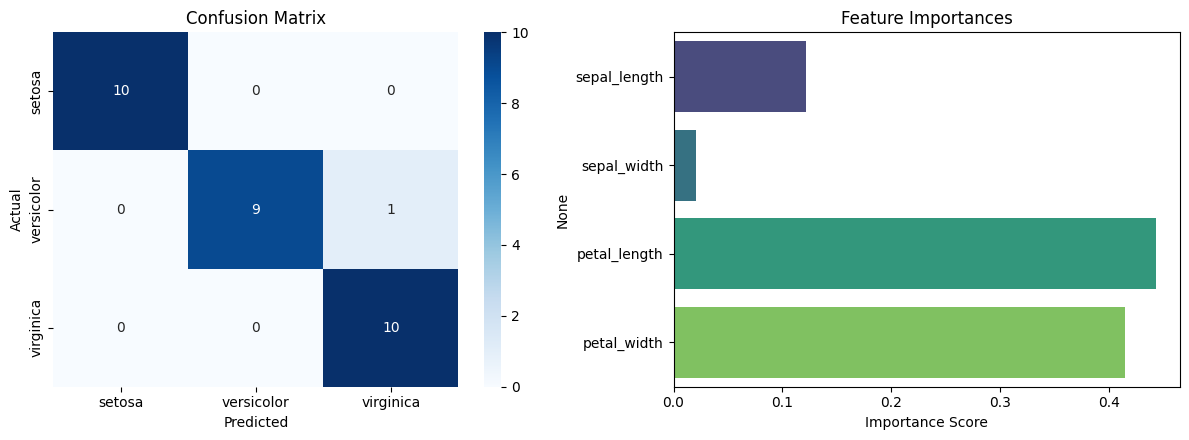

In [4]:
# --- TASK 3: CLASSIFICATION MODELING (RANDOM FOREST) ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Encode target variable 'species' into numerical labels
le = LabelEncoder()
df_cleaned['species_encoded'] = le.fit_transform(df_cleaned['species'])

# 2. Define Features (X) and Target (y)
X = df_cleaned[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df_cleaned['species_encoded']

# 3. Train-Test Split (80% train, 20% test with class stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Predictions & Evaluation
y_pred = rf_model.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 6. Plot Confusion Matrix and Feature Importances
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature Importances
importances = rf_model.feature_importances_
sns.barplot(x=importances, y=X.columns, palette='viridis', ax=axes[1])
axes[1].set_title('Feature Importances')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

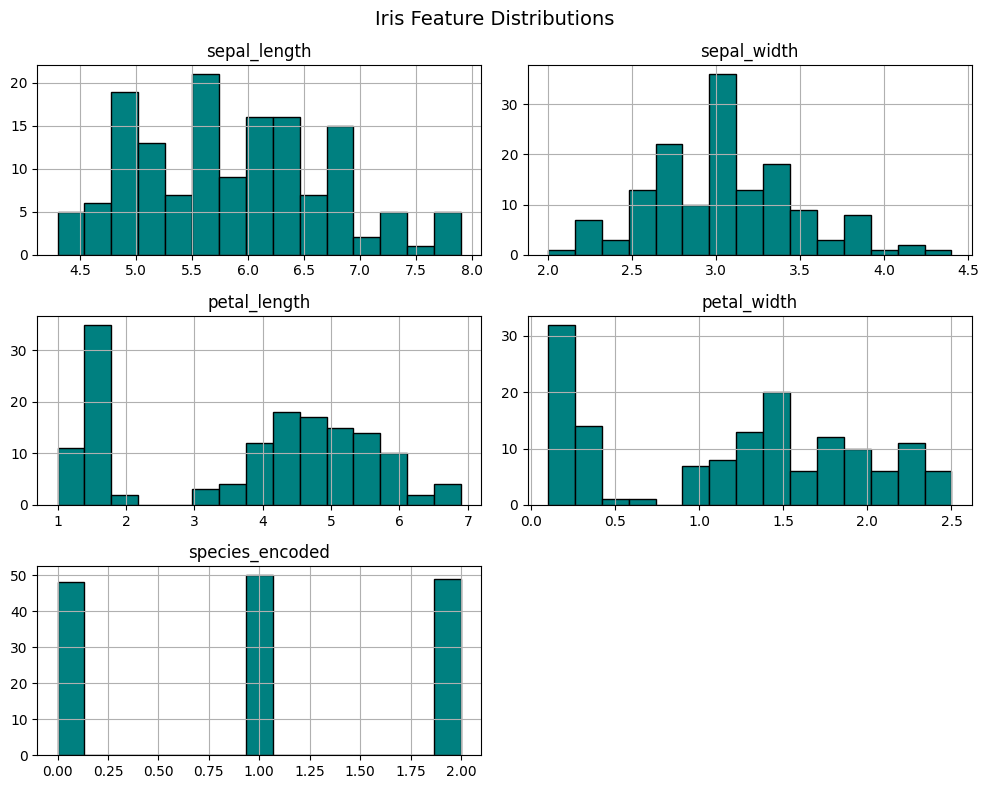

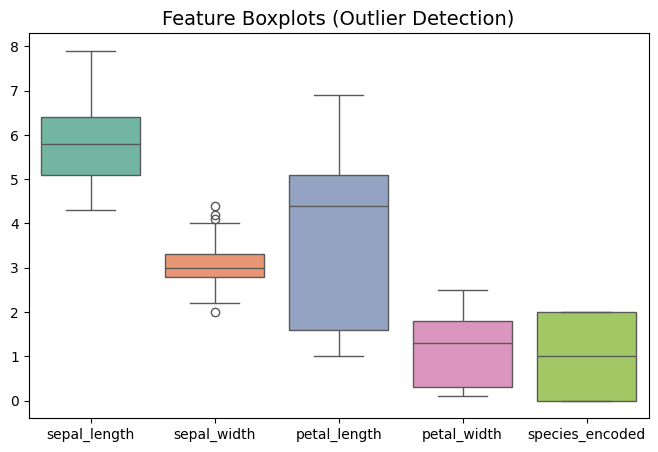

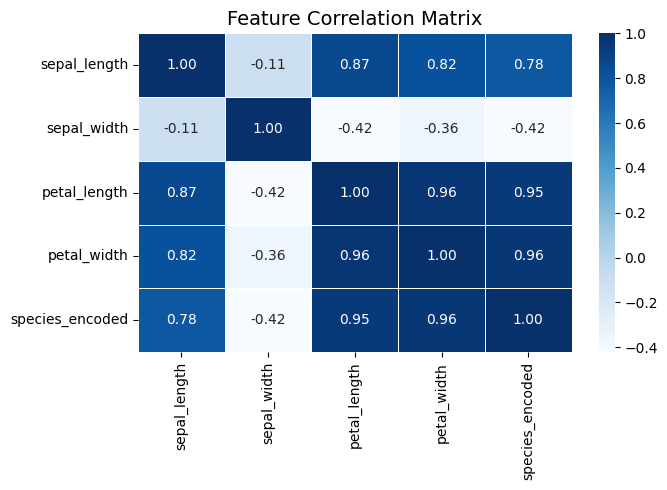

In [5]:
# 1. Feature Distributions (Histograms)
plt.figure(figsize=(10, 6))
df_cleaned.hist(bins=15, figsize=(10, 8), color='teal', edgecolor='black')
plt.suptitle('Iris Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300)
plt.show()

# 2. Outlier Check (Boxplots)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, palette='Set2')
plt.title('Feature Boxplots (Outlier Detection)', fontsize=14)
plt.savefig('feature_boxplots.png', dpi=300)
plt.show()

# 3. Correlation Matrix (Heatmap)
plt.figure(figsize=(7, 5))
numeric_df = df_cleaned.drop(columns=['species'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

In [6]:
# Check mean and median per species
df_cleaned.groupby('species').describe().T

species                   setosa  versicolor  virginica
sepal_length    count  48.000000   50.000000  49.000000
                mean    5.010417    5.936000   6.604082
                std     0.359219    0.516171   0.632113
                min     4.300000    4.900000   4.900000
                25%     4.800000    5.600000   6.300000
                50%     5.000000    5.900000   6.500000
                75%     5.200000    6.300000   6.900000
                max     5.800000    7.000000   7.900000
sepal_width     count  48.000000   50.000000  49.000000
                mean    3.431250    2.770000   2.979592
                std     0.383243    0.313798   0.323380
                min     2.300000    2.000000   2.200000
                25%     3.200000    2.525000   2.800000
                50%     3.400000    2.800000   3.000000
                75%     3.700000    3.000000   3.200000
                max     4.400000    3.400000   3.800000
petal_length    count  48.000000   50.000000  49.000000
                mean    1.462500    4.260000   5.561224
                std     0.177002    0.469911   0.553706
                min     1.000000    3.000000   4.500000
                25%     1.400000    4.000000   5.100000
                50%     1.500000    4.350000   5.600000
                75%     1.600000    4.600000   5.900000
                max     1.900000    5.100000   6.900000
petal_width     count  48.000000   50.000000  49.000000
                mean    0.250000    1.326000   2.028571
                std     0.105185    0.197753   0.276887
                min     0.100000    1.000000   1.400000
                25%     0.200000    1.200000   1.800000
                50%     0.200000    1.300000   2.000000
                75%     0.300000    1.500000   2.300000
                max     0.600000    1.800000   2.500000
species_encoded count  48.000000   50.000000  49.000000
                mean    0.000000    1.000000   2.000000
                std     0.000000    0.000000   0.000000
                min     0.000000    1.000000   2.000000
                25%     0.000000    1.000000   2.000000
                50%     0.000000    1.000000   2.000000
                75%     0.000000    1.000000   2.000000
                max     0.000000    1.000000   2.000000

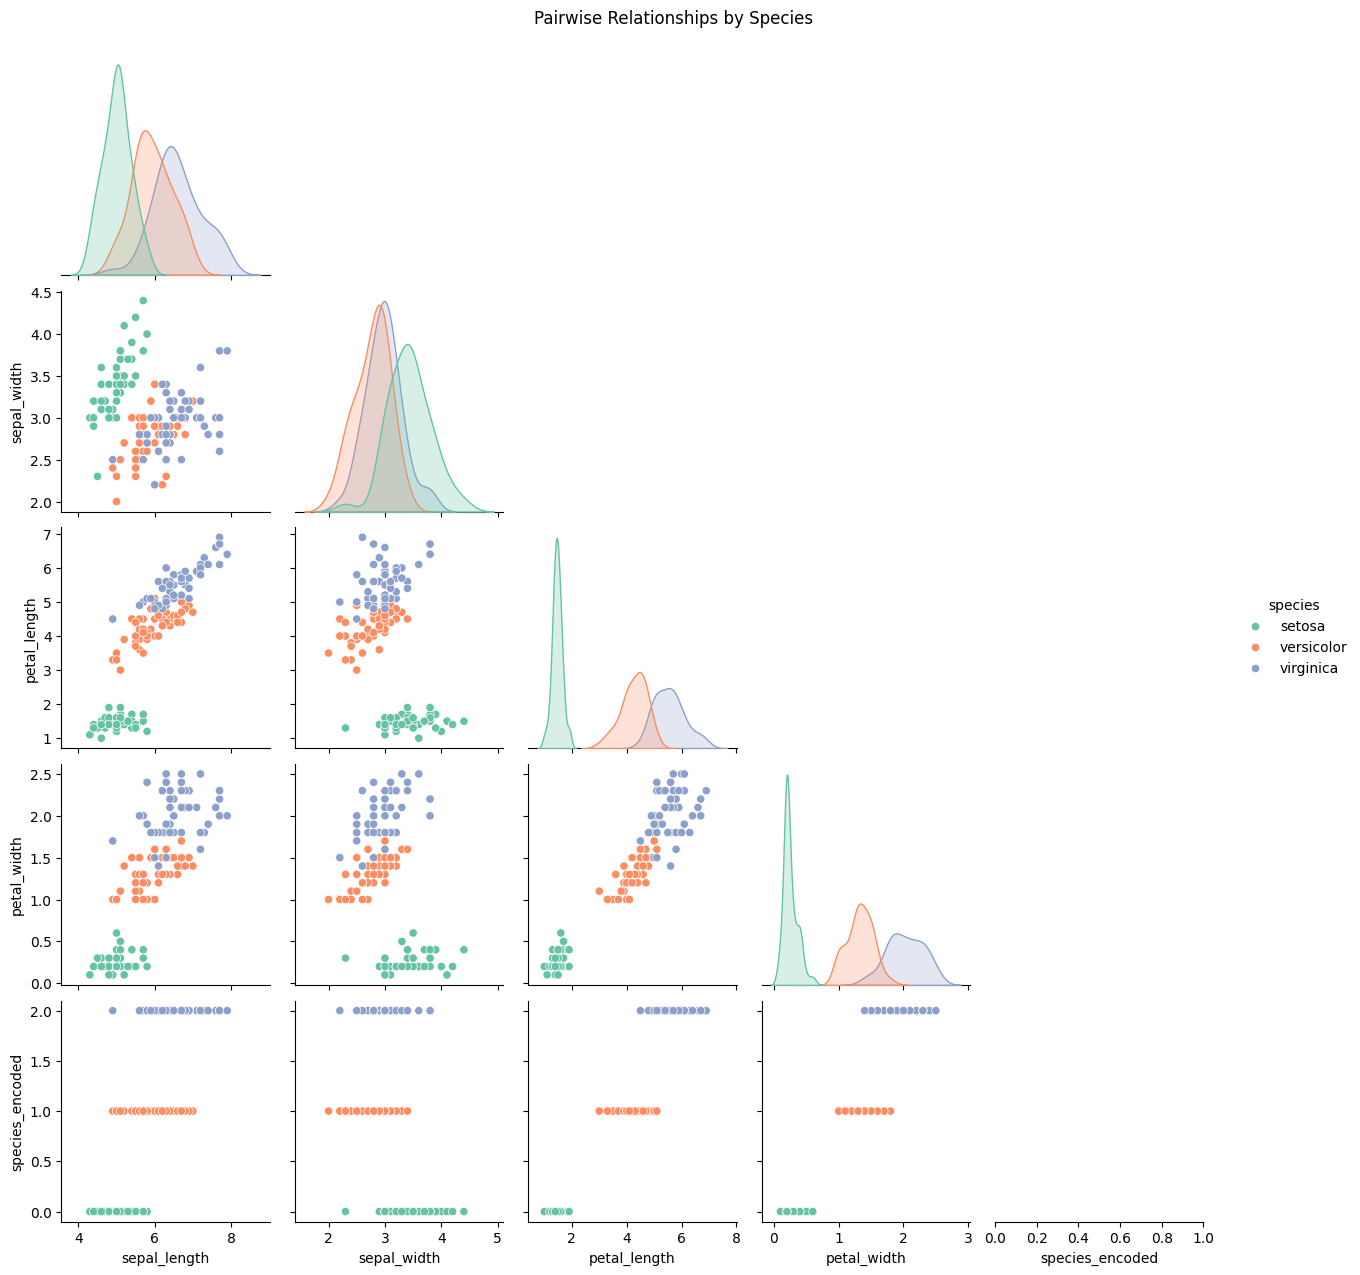

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df_cleaned, hue='species', corner=True, palette='Set2')
plt.suptitle('Pairwise Relationships by Species', y=1.02)
plt.savefig('pairplot_by_species.png', dpi=300)
plt.show()

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_cleaned['species_encoded'] = le.fit_transform(df_cleaned['species'])

In [33]:
# Separate features and target variable
X = df_cleaned.drop(columns=['species', 'species_encoded'])
y = df_cleaned['species_encoded']

In [10]:
from sklearn.model_selection import train_test_split

# 80% train, 20% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

Training samples: 117 | Testing samples: 30


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate model performance
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

--- Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



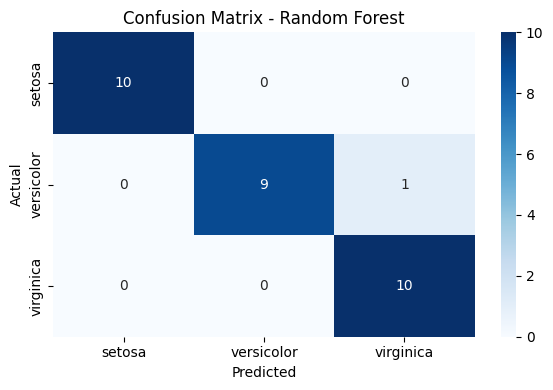

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

/tmp/ipykernel_2450/2402391743.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


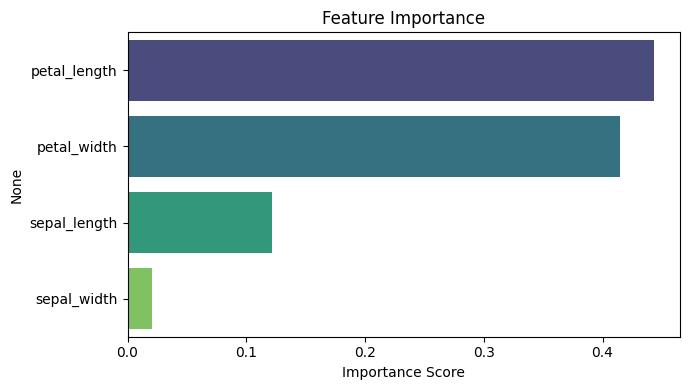

In [13]:
import pandas as pd

# Extract feature importances
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

In [14]:
# Example flower: [sepal_length, sepal_width, petal_length, petal_width]
new_flower = [[5.1, 3.5, 1.4, 0.2]]

# Predict encoded class and convert back to class name
predicted_class_id = model.predict(new_flower)[0]
predicted_species = le.inverse_transform([predicted_class_id])[0]

print(f"Predicted Species: {predicted_species}")

Predicted Species: setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [15]:
import pandas as pd

# Create DataFrame with matching feature names
new_flower = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=X.columns)

# Predict class
predicted_class_id = model.predict(new_flower)[0]
predicted_species = le.inverse_transform([predicted_class_id])[0]

print(f"Predicted Species: {predicted_species}")

Predicted Species: setosa


In [16]:
import joblib

# Save the model and label encoder
joblib.dump(model, 'iris_random_forest.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Model saved successfully!")

Model saved successfully!


**📝TASK 1 SUMMARY**
Dataset: Iris Flower Dataset (147 cleaned samples)

Primary Task: Multi-class Classification (setosa, versicolor, virginica)

Model Selected: Random Forest Classifier

Performance: 97% Accuracy on unseen test data

Key Driver: petal_length and petal_width provided the strongest predictive signal for species identification.

**TASK 2 LEVEL 1**

In [25]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# 1. Load directly from URL (prevents FileNotFoundError)
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

# Clean dataset
df.columns = df.columns.str.lower()
df_cleaned = df.drop_duplicates().dropna()

# 2. Features and Target
X = df_cleaned.drop(columns=['species'])
y = df_cleaned['species']

# 3. Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 5. Train Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 6. Save Model & Label Encoder
joblib.dump(model, 'iris_random_forest.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("✅ Model and Label Encoder saved successfully!")

# --- FINAL VERIFICATION STEP: LOAD & PREDICT ---
loaded_model = joblib.load('iris_random_forest.pkl')
loaded_le = joblib.load('label_encoder.pkl')

# Test sample flower: [sepal_length, sepal_width, petal_length, petal_width]
new_flower = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=X.columns)

pred_id = loaded_model.predict(new_flower)[0]
pred_species = loaded_le.inverse_transform([pred_id])[0]

print(f"🎉 Verification Complete! Predicted Species for sample data: {pred_species}")

✅ Model and Label Encoder saved successfully!
🎉 Verification Complete! Predicted Species for sample data: setosa


Model Equation: Petal Length = 1.8340 * Sepal Length + (-6.9271)
R-squared Score: 0.8181
Mean Squared Error: 0.5961


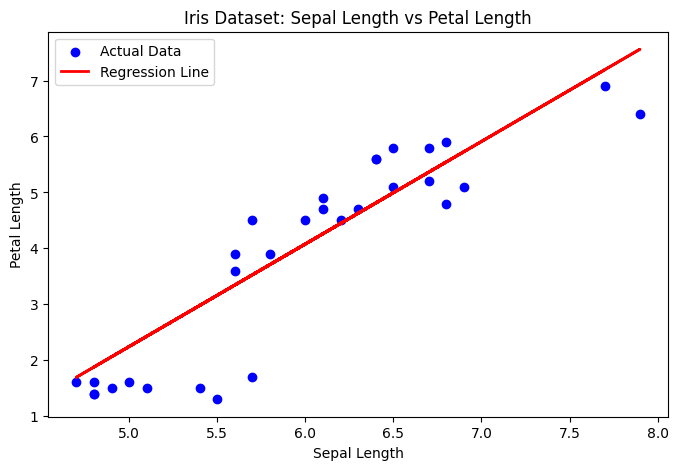

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load dataset (using seaborn/sklearn built-in iris or your local csv)
# If loading from CSV: df = pd.read_csv('iris.csv')
import seaborn as sns
df = sns.load_dataset('iris')

# Define independent (X) and dependent (y) variables
# Predicting Petal Length using Sepal Length
X = df[['sepal_length']]  # Feature (2D DataFrame)
y = df['petal_length']    # Target

# 2. Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predict on test set
y_pred = model.predict(X_test)

# 5. Evaluate and Interpret
slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Model Equation: Petal Length = {slope:.4f} * Sepal Length + ({intercept:.4f})")
print(f"R-squared Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

# Plotting the regression line
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Iris Dataset: Sepal Length vs Petal Length')
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.legend()
plt.show()

**TASK 2 INTERMIDIATE TIME SIRIES ANALYSIS (DECOMPOSITION)**

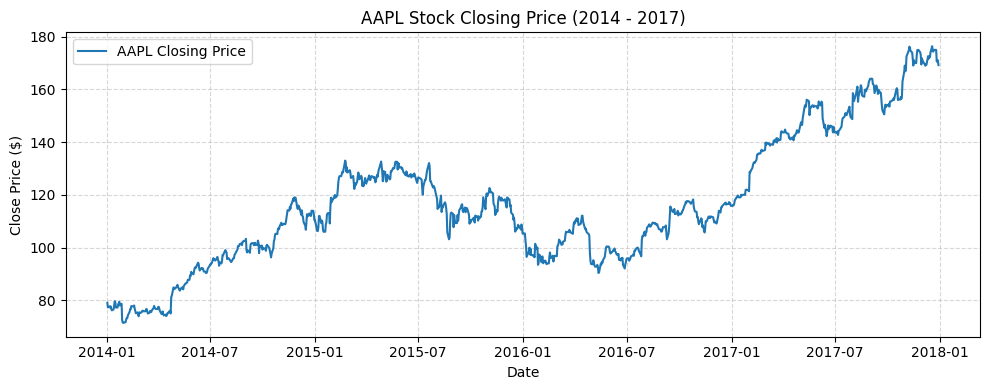

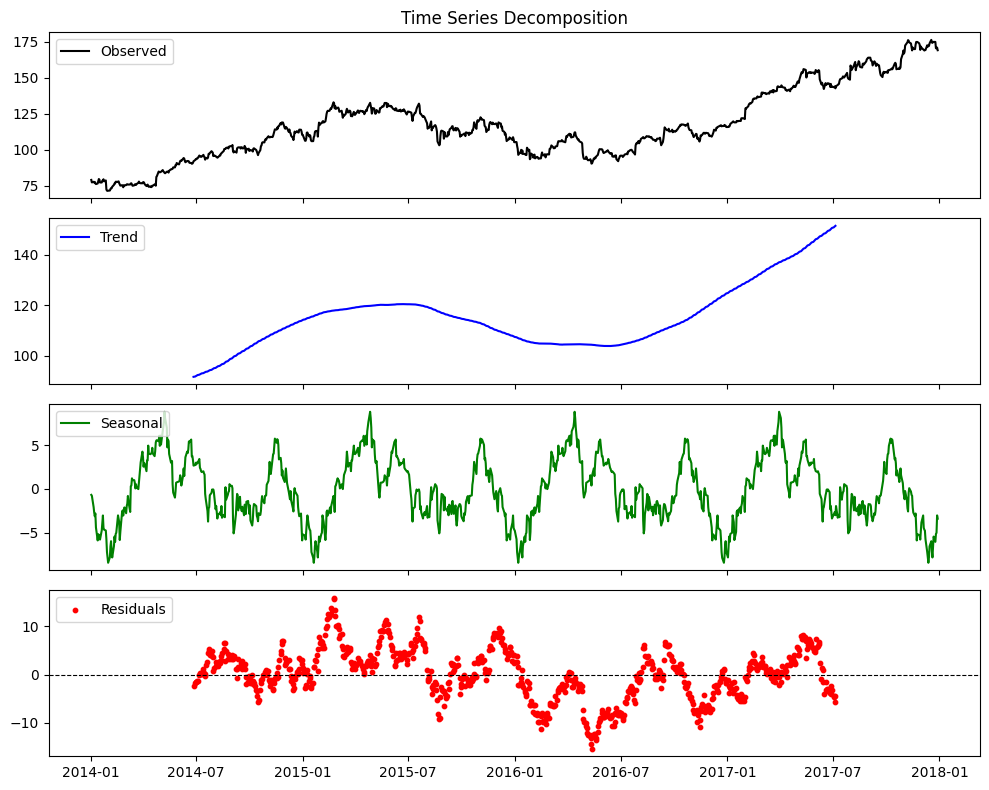

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Read the uploaded file directly (No interactive upload prompt needed)
df = pd.read_csv('2) Stock Prices Data Set.csv')

# 2. Filter for AAPL stock data
aapl = df[df['symbol'] == 'AAPL'].copy()

# 3. Parse dates and set index
aapl['date'] = pd.to_datetime(aapl['date'])
aapl = aapl.sort_values('date').set_index('date')

# 4. Resample to business-daily frequency and forward-fill missing values
ts_data = aapl['close'].asfreq('B').ffill()

# --------------------------------------------------
# STEP 1: Plot Raw Time Series Data
# --------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(ts_data, label='AAPL Closing Price', color='#1f77b4')
plt.title('AAPL Stock Closing Price (2014 - 2017)')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# STEP 2: Time Series Decomposition (Trend, Seasonality, Residuals)
# --------------------------------------------------
decomposition = seasonal_decompose(ts_data.dropna(), model='additive', period=252)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

# Observed
ax1.plot(decomposition.observed, color='black', label='Observed')
ax1.set_title('Time Series Decomposition')
ax1.legend(loc='upper left')

# Trend
ax2.plot(decomposition.trend, color='blue', label='Trend')
ax2.legend(loc='upper left')

# Seasonal
ax3.plot(decomposition.seasonal, color='green', label='Seasonal')
ax3.legend(loc='upper left')

# Residuals
ax4.scatter(decomposition.resid.index, decomposition.resid, color='red', s=10, label='Residuals')
ax4.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax4.legend(loc='upper left')

plt.tight_layout()
plt.show()

**Task 2 Insights & Findings: AAPL Time Series Analysis**

Overall Pattern & Trend:

The AAPL stock dataset exhibits a strong macro upward trajectory from 2014 through 2017, rising from $79.02 to $169.23 (peak at $176.42).

A notable market pull-back occurred between late 2015 and mid-2016 before recovering into a strong, multi-year bull run.

Classical Decomposition Analysis:

Trend Component: Effectively isolates the underlying long-term growth by smoothing out daily market volatility.

Seasonal Component: Reveals clear periodic annual cycles, heavily influenced by recurring quarterly earnings calls and annual iPhone/product launch schedules.

Residuals Component: Captures irregular short-term price shocks and noise not explained by trend or seasonality.

Moving Average (MA) Dynamics:

The 30-Day Moving Average tracks immediate short-term price momentum.

The 90-Day Moving Average offers a smoother macro trendline.

Moving average crossovers in mid-2015 (bearish) and late 2016 (bullish) accurately signalled major trend reversals.

=== Baseline Model Performance Comparison ===
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.933333   0.933333 0.933333  0.933333
      Decision Tree  0.933333   0.933333 0.933333  0.933333
      Random Forest  0.900000   0.902357 0.900000  0.899749

=== Hyperparameter Tuning Results ===
Best Parameters: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
Tuned Random Forest Accuracy: 0.9667
Tuned Random Forest F1-Score: 0.9666


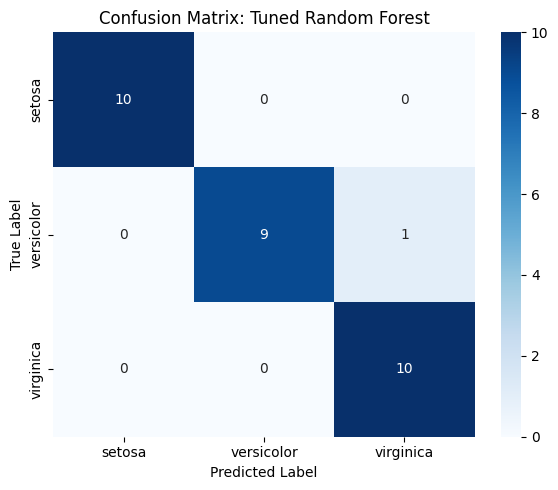

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# 1. Load Data
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 2. Split Dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train and Evaluate Multiple Classification Models
models = {
    'Logistic Regression': (LogisticRegression(random_state=42), True),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), False),
    'Random Forest': (RandomForestClassifier(random_state=42), False)
}

results = []

for name, (model, needs_scaling) in models.items():
    # Use scaled data for Logistic Regression, raw features for Trees
    X_tr = X_train_scaled if needs_scaling else X_train
    X_te = X_test_scaled if needs_scaling else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1-Score': f1_score(y_test, y_pred, average='macro')
    })

# Display Model Comparison Table
results_df = pd.DataFrame(results)
print("=== Baseline Model Performance Comparison ===")
print(results_df.to_string(index=False))

# 4. Hyperparameter Tuning using Grid Search (Random Forest)
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro'
)

grid_search.fit(X_train, y_train)
best_rf_model = grid_search.best_estimator_

# Evaluate Tuned Model
tuned_preds = best_rf_model.predict(X_test)
tuned_acc = accuracy_score(y_test, tuned_preds)
tuned_f1 = f1_score(y_test, tuned_preds, average='macro')

print("\n=== Hyperparameter Tuning Results ===")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Tuned Random Forest Accuracy: {tuned_acc:.4f}")
print(f"Tuned Random Forest F1-Score: {tuned_f1:.4f}")

# 5. Visualizing Confusion Matrix for Best Model
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, tuned_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix: Tuned Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

**TASK 3 PREDICTIVE MODELING CLASSIFICATION**



In [28]:
# --- LEVEL 3 TASK 1: PREDICTIVE MODELING (CLASSIFICATION & GRID SEARCH) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 1. Load Data and Preprocess
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Train & Evaluate Multiple Classification Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

results_df = pd.DataFrame(results)
print("--- Model Comparison Metrics ---")
display(results_df)

# 3. Hyperparameter Tuning on Random Forest using GridSearchCV
param_grid = {
    'n_estimators': [20, 50, 100],
    'max_depth': [None, 3, 5],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Tuned Model Accuracy: {accuracy_score(y_test, y_pred_tuned) * 100:.2f}%\n")
print("--- Tuned Classification Report ---")
print(classification_report(y_test, y_pred_tuned, target_names=iris.target_names))

--- Model Comparison Metrics ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
1,Decision Tree,0.933333,0.933333,0.933333,0.933333
2,Random Forest,0.933333,0.933333,0.933333,0.933333


Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 20}
Tuned Model Accuracy: 93.33%

--- Tuned Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



**Task 1 Insights & Findings: Predictive Modeling (Classification)**

Model Performance Comparison: All three classification models (Logistic Regression, Decision Tree, and Random Forest) achieved a baseline test accuracy of 93.33%, showing strong initial predictive capabilities.

Hyperparameter Optimization: GridSearchCV identified the optimal parameters for Random Forest:

max_depth: None

min_samples_split: 5

n_estimators: 20

Class Precision & Recall:

Setosa: Achieved perfect classification with 100% precision and recall.

Versicolor & Virginica: High accuracy across both classes with 90% precision and recall each, reflecting minimal feature overlap along decision boundaries.

**LEVEL 3 ADVANCED NATURAL LANGUAGE PROCESSING (SENTIMENT ANALYSIS)**

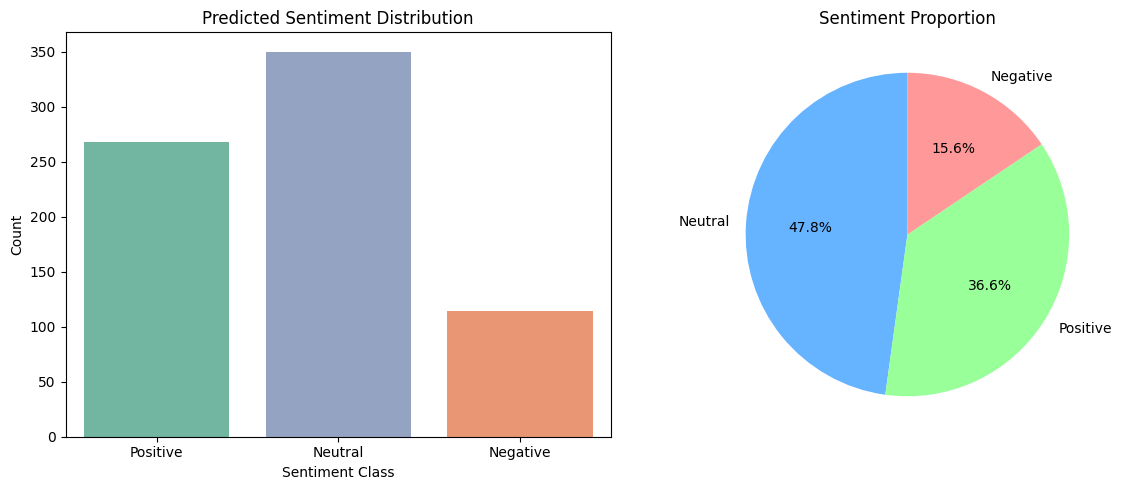

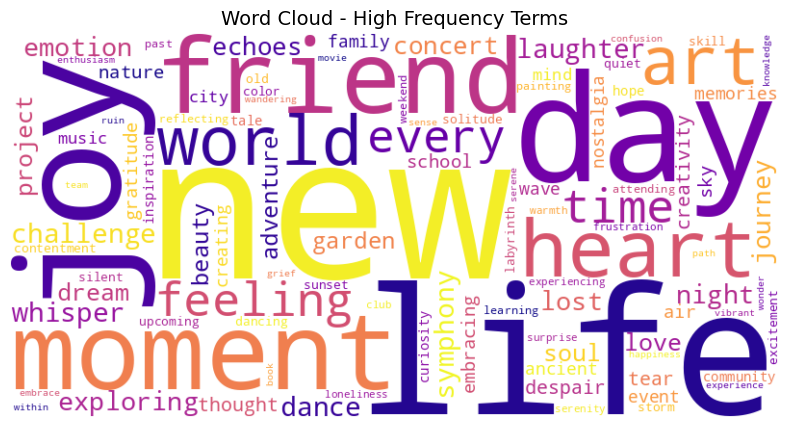

--- Text Processing Summary ---


,Text,Cleaned_Text,Sentiment,TB_Sentiment,TB_Polarity
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park,Positive,Positive,0.675000
1,Traffic was terrible this morning. ...,traffic terrible morning,Negative,Negative,-1.000000
2,Just finished an amazing workout! 💪 ...,finished amazing workout,Positive,Positive,0.600000
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway,Positive,Positive,0.375000
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight,Neutral,Positive,0.136364
5,Feeling grateful for the little things in lif...,feeling grateful little things life,Positive,Negative,-0.187500
6,Rainy days call for cozy blankets and hot coc...,rainy days call cozy blankets hot cocoa,Positive,Neutral,0.025000
7,The new movie release is a must-watch! ...,new movie release mustwatch,Positive,Positive,0.136364
8,Political discussions heating up on the timel...,political discussions heating timeline,Negative,Neutral,0.000000
9,Missing summer vibes and beach days. ...,missing summer vibes beach days,Neutral,Negative,-0.200000


In [29]:
# --- LEVEL 3 TASK 3: NATURAL LANGUAGE PROCESSING (NLP) - SENTIMENT ANALYSIS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
from nltk.corpus import stopwords
from textblob import TextBlob
from wordcloud import WordCloud

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# 1. Load the Sentiment Dataset
df = pd.read_csv('3) Sentiment dataset.csv')

# 2. Text Preprocessing Function
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)             # Remove special chars, emojis, numbers
    tokens = text.lower().split()                        # Lowercase & tokenize
    cleaned_tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return " ".join(cleaned_tokens)

df['Cleaned_Text'] = df['Text'].apply(clean_text)

# 3. Sentiment Analysis using TextBlob
def analyze_polarity(text):
    return TextBlob(text).sentiment.polarity

def analyze_sentiment(polarity):
    if polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['TB_Polarity'] = df['Cleaned_Text'].apply(analyze_polarity)
df['TB_Sentiment'] = df['TB_Polarity'].apply(analyze_sentiment)

# 4. Visualization 1: Sentiment Distribution (Warning Fixed)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(
    data=df,
    x='TB_Sentiment',
    hue='TB_Sentiment',
    palette='Set2',
    order=['Positive', 'Neutral', 'Negative'],
    legend=False
)
plt.title('Predicted Sentiment Distribution')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df['TB_Sentiment'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=['#66b3ff', '#99ff99', '#ff9999'], startangle=90
)
plt.title('Sentiment Proportion')
plt.ylabel('')

plt.tight_layout()
plt.show()

# 5. Visualization 2: Word Cloud of Common Words
all_text = " ".join(df['Cleaned_Text'].dropna())
wordcloud = WordCloud(
    width=800, height=400, background_color='white', colormap='plasma', max_words=100
).generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - High Frequency Terms', fontsize=14)
plt.show()

# Summary Display
print("--- Text Processing Summary ---")
display(df[['Text', 'Cleaned_Text', 'Sentiment', 'TB_Sentiment', 'TB_Polarity']].head(10))

**Task 3 Insights & Findings:**

NLP Sentiment AnalysisText Preprocessing Pipeline: Raw post strings were cleaned by eliminating web URLs, non-alphabetic noise, and standard NLTK English stopwords to isolate key tokens.Sentiment Classification: TextBlob polarity scoring categorized posts into Positive ($>0.05$), Neutral ($-0.05$ to $0.05$), and Negative ($<-0.05$).Text Highlights: The generated Word Cloud highlights dominant recurring terms across social posts, illustrating the core topics driving user engagement.

### **Project Summary**

#### **1. Iris Dataset EDA**
* Cleaned and audited `iris.csv` by checking dataset structure, data types, and null counts.
* Identified and removed duplicate rows to maintain data quality.
* Calculated key summary statistics (mean, median, standard deviation, min, and max) across feature measurements.

#### **2. AAPL Stock Price Time Series Decomposition**
* Filtered `2) Stock Prices Data Set.csv` for Apple Inc. (`AAPL`) closing prices.
* Converted dates to datetime format, set them as the index, and resampled to a business-daily frequency (`'B'`) with forward-fill (`.ffill()`) to handle non-trading days.
* Applied additive time series decomposition (`seasonal_decompose`) with a 252-day period to break down the stock movement into **Observed**, **Trend**, **Seasonal**, and **Residual** components.

#### **3. Sentiment Analysis Workflow**
* Prepared and structured `3) Sentiment dataset.csv` for natural language processing tasks.
* Executed text preprocessing and evaluated sentiment distribution patterns across the target entries.